# One-hour cloud forecasting over Ireland

This notebook uses hourly satellite images from 2024 to answer two questions. First, can a CNN estimate next-hour cloud amount (`clamt`) at five weather stations? Second, can a CNN–LSTM predict the next-hour cloud mask and cloud-top height over the full satellite grid?

Both experiments use chronological training, validation, and test periods. The station experiment uses station CSV measurements as targets and current-hour inputs. The map experiment uses the satellite NPZ for both inputs and targets. Each model is compared with a persistence forecast on the same evaluation hours.

## Install packages

**Input:** The active Python environment. **Output:** The packages needed for the notebook. Run this cell once, then restart the kernel if the environment asks you to.

In [1]:
%pip install matplotlib numpy pandas torch


Note: you may need to restart the kernel to use updated packages.


**Input:** Installed packages. **Output:** Imports for array handling, plotting, and neural-network training. Both experiments use these imports.

The imported libraries support the satellite and station workflows that follow.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import torch, torch.nn as nn
import pandas as pd
import copy

torch.cuda.is_available()


False

**Input:** The current PyTorch environment. **Output:** Version and GPU availability, which determine the available training device.

In [3]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())


PyTorch: 2.14.0+cpu
CUDA available: False
GPU count: 0


## Load and check the hourly data

The satellite frames and station observations must refer to the same UTC hours before any samples are constructed.

**Input:** The 2024 satellite NPZ file. **Output:** Its arrays and shapes: `times`, `cloud_mask`, `cth_km`, `lat`, and `lon`. Mask value `3` indicates missing satellite pixels, not clear sky.

In [4]:
sat_data = np.load( 
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)
print(sat_data.files)


['times', 'cloud_mask', 'cth_km', 'lat', 'lon']


**Input:** Paths to the five station CSV files. **Output:** A function that extracts their timestamp and `clamt` measurements; `clamt` is cloud amount on the 0–8 okta scale.

In [5]:
csv_name = ["hly532.csv", "hly3904_subset.csv", "hly4935_subset.csv",
            "hly518_subset.csv", "hly3723_subset.csv"]
dates = []

def get_target_data(csv_name):
    data = pd.read_csv("data/raw/stations/" + csv_name, skiprows=41,
                       usecols=["date", "clamt"], low_memory=False)
    data["date"] = pd.to_datetime(data["date"], format="%d-%b-%Y %H:%M")
    data = data.loc[data["date"].dt.year == 2024].copy()
    if data["date"].duplicated().any():
        raise ValueError(f"Duplicate hours in {csv_name}")
    target = pd.to_numeric(data["clamt"], errors="coerce")
    target = target.where(target.between(0, 8)).to_numpy(dtype=np.float32)
    dates.append(data["date"].to_numpy())
    print(f"{csv_name}: {len(target)} hours; missing clamt: {np.isnan(target).sum()}")
    return target


**Input:** The station CSV filenames. **Output:** An hourly `clamt` series and timestamps for each station.

In [6]:
target_data = []

for csv in csv_name:
    target_data.append(get_target_data(csv))


hly532.csv: 8784 hours; missing clamt: 0
hly3904_subset.csv: 8784 hours; missing clamt: 0
hly4935_subset.csv: 8784 hours; missing clamt: 0
hly518_subset.csv: 8784 hours; missing clamt: 0
hly3723_subset.csv: 8784 hours; missing clamt: 0


**Input:** The five timestamp series. **Output:** Confirmation that their rows refer to the same hours; mismatched rows would misalign inputs and targets.

In [7]:
dates = np.array(dates).T
print(f"dates shape: {dates.shape}")

for date in dates:
    assert np.all(date[0] == date[1 :]), "Dates are not the same across all CSV files."


dates shape: (8784, 5)


**Input:** The station cloud-amount series. **Output:** One array with stations in a fixed order, used throughout training and evaluation.

In [8]:
target_data = np.array(target_data)
print(f"target_data shape: {target_data.shape}")


target_data shape: (5, 8784)


**Input:** Satellite times and station times. **Output:** A check that the satellite frames and station observations line up hour by hour.

In [9]:
cloud_mask = sat_data["cloud_mask"]
cth_km = sat_data["cth_km"]
sat_times = sat_data["times"]

# station rows must be the same hours in the same order as the satellite frames (all UTC)
assert np.array_equal(dates[:, 0].astype("datetime64[us]"), sat_times)

# one True/False per HOUR: missing only if the WHOLE frame is "no data" (3)


**Input:** Satellite masks and station observations. **Output:** `hour_ok`, identifying hours with at least one valid satellite pixel and available station measurements. A missing satellite frame can invalidate several overlapping six-hour samples.

In [10]:
sat_ok = ~(cloud_mask == 3).all(axis=(1, 2))                 # (8784,)

# target_data is (stations, hours): an hour is usable only if EVERY station has a cloud amount,
# so collapse the station axis -> one value per hour
target_ok = ~np.isnan(target_data).any(axis=0)               # (8784,)

hour_ok = sat_ok & target_ok
print(f"hours: {len(hour_ok)}, missing: {(~hour_ok).sum()}")
print("missing hours:", sat_times[~hour_ok])


hours: 8784, missing: 14
missing hours: ['2024-06-27T07:00:00.000000' '2024-07-23T22:00:00.000000'
 '2024-07-23T23:00:00.000000' '2024-07-24T00:00:00.000000'
 '2024-07-24T01:00:00.000000' '2024-07-24T02:00:00.000000'
 '2024-07-24T03:00:00.000000' '2024-07-24T04:00:00.000000'
 '2024-08-17T13:00:00.000000' '2024-08-17T14:00:00.000000'
 '2024-08-17T15:00:00.000000' '2024-08-17T16:00:00.000000'
 '2024-08-17T17:00:00.000000' '2024-09-04T08:00:00.000000']


**Input:** Satellite cloud mask and cloud-top height. **Output:** Two image channels per hour, cloud presence and height in kilometres, each on the 90 × 120 grid.

In [11]:
# Build 2 channels per timestep -> frames: (hours, 2, 90, 120)
#   channel 0: cloud      1 = cloud, 0 = clear (clear sea / clear land / no-data pixel)
#   channel 1: height_km  cloud top height in km, 0 where clear
# Sea vs land never changes, so it's not worth a channel of its own.

cloud = (cloud_mask == 2).astype(np.float16)

# cth_km is NaN only in the 14 missing hours (those samples get dropped anyway) -> 0.
# CTH comes on a coarser grid, so it spills onto some clear pixels -- zero it wherever
# the cloud mask says clear so the two channels agree.
height_km = np.nan_to_num(cth_km, nan=0.0) * cloud

frames = np.stack([cloud, height_km], axis=1)    # float16 to save memory (~380 MB)



print(f"frames shape: {frames.shape}  (hours, channels, lat, lon)")
print(f"height range: {height_km.min():.2f} - {height_km.max():.2f} km")


frames shape: (8784, 2, 90, 120)  (hours, channels, lat, lon)
height range: 0.00 - 15.04 km


**Input:** Temporary image arrays. **Output:** Released memory after the model input frames have been constructed.

In [12]:
import gc
del cloud, height_km, cth_km, sat_ok
gc.collect()


141

## Experiment 1: station cloud amount after one hour

Six hourly satellite frames and the current station observations are used to estimate the change in `clamt` at five stations one hour ahead.

**Input:** Valid hourly frames. **Output:** Sample end times with six consecutive input frames and an available target at `t + 1`; `K = 6`, `H = 1`.

In [13]:
K = 6  # six consecutive hourly satellite maps
H = 1  # one-hour clamt forecast, matching the next-hour map
sample_t = np.array([
    t for t in range(K - 1, len(hour_ok) - H)
    if hour_ok[t - K + 1:t + 1].all() and hour_ok[t + H]
])
print(f"possible samples: {len(hour_ok) - H - K + 1}, kept: {len(sample_t)}, "
      f"dropped: {len(hour_ok) - H - K + 1 - len(sample_t)}")


possible samples: 8778, kept: 8740, dropped: 38


**Input:** The first six-frame sample. **Output:** Its image and five-station target shapes, to confirm the sample indices before training.

In [14]:
t = sample_t[0]
X0 = frames[t - K + 1:t + 1]        # (K, 2, 90, 120): K timesteps x 2 channels
y0 = target_data[:, t + H]          
print(X0.shape, y0)


(6, 2, 90, 120) [1. 7. 6. 4. 2.]


**Input:** Current and next-hour station measurements. **Output:** The target change `clamt(t + 1) − clamt(t)` for each station. Adding the predicted change to the current value gives the forecast.

In [15]:
clamt_now    = target_data[:, sample_t].T        # (samples, stations) cloud amount at the last input hour t
clamt_future = target_data[:, sample_t + H].T    # (samples, stations) cloud amount at t + H
y = clamt_future - clamt_now                     # (samples, stations) change in oktas over the next H hours
print(f"y shape: {y.shape}  (samples, stations)")


y shape: (8740, 5)  (samples, stations)


**Input:** Current station cloud amounts and target timestamps. **Output:** Seven extra features: five current `clamt` values and sine/cosine of the target hour. The cyclic hour encoding keeps 23:00 and 00:00 adjacent.

In [16]:
# extra inputs per sample, joined to the CNN features before the final layer
#   clamt_now / 8        -> (samples, 5)  current cloud amount at each station, 0-1
#   sin/cos hour of day  -> (samples, 2)  hour of the TARGET (t + H), so 23h sits next to 0h
target_hour = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
extra = np.column_stack([
    clamt_now / 8.0,
    np.sin(2 * np.pi * target_hour / 24),
    np.cos(2 * np.pi * target_hour / 24),
]).astype(np.float32)
print(f"extra shape: {extra.shape}  (samples, 5 stations + 2 hour)")


extra shape: (8740, 7)  (samples, 5 stations + 2 hour)


**Input:** The full hourly timeline and each sample window. **Output:** Chronological 70%/15%/15% boundaries and flags that keep every input and target inside one period.

In [17]:
n_hours = len(sat_times)
train_end = int(0.70 * n_hours)
validation_end = int(0.85 * n_hours)
first_input = sample_t - K + 1
target_hour_index = sample_t + H
inside_train = target_hour_index < train_end
inside_validation = (first_input >= train_end) & (target_hour_index < validation_end)
inside_test = first_input >= validation_end


**Input:** Split flags. **Output:** Train, validation, and test sample indices and their time ranges, with no input-hour overlap across periods.

In [18]:
idx = np.arange(len(sample_t))
train_idx = idx[inside_train]
val_idx = idx[inside_validation]
test_idx = idx[inside_test]

def used_station_hours(indices):
    ends = sample_t[indices]
    return set(np.concatenate([ends - offset for offset in range(K)] + [ends + H]))

assert used_station_hours(train_idx).isdisjoint(used_station_hours(val_idx))
assert used_station_hours(train_idx).isdisjoint(used_station_hours(test_idx))
assert used_station_hours(val_idx).isdisjoint(used_station_hours(test_idx))
for label, rows in (("Train", train_idx), ("Validation", val_idx), ("Test", test_idx)):
    target_times = sat_times[sample_t[rows] + H]
    print(f"{label}: {len(rows)} samples | {target_times[0]} to {target_times[-1]}")
print("No shared input or target hours between splits.")


Train: 6104 samples | 2024-01-01T06:00:00.000000 to 2024-09-13T03:00:00.000000
Validation: 1312 samples | 2024-09-13T10:00:00.000000 to 2024-11-07T01:00:00.000000
Test: 1312 samples | 2024-11-07T08:00:00.000000 to 2024-12-31T23:00:00.000000
No shared input or target hours between splits.


### Persistence reference

**Input:** Current and next-hour station observations. **Output:** Validation and test RMSE in oktas when the next-hour value is assumed equal to the current value. This is the reference for the learned forecasts.

In [19]:
def overall_rmse(predicted, observed):
    return np.sqrt(np.mean((predicted - observed) ** 2))

for name, indices in (("Validation", val_idx), ("Test", test_idx)):
    print(f"{name} persistence RMSE: "
          f"{overall_rmse(clamt_now[indices], clamt_future[indices]):.3f} oktas")


Validation persistence RMSE: 1.206 oktas
Test persistence RMSE: 1.225 oktas


**Input:** The active environment. **Output:** `scikit-learn`, required for the linear comparison model.

In [20]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


**Input:** `scikit-learn`. **Output:** The `LinearRegression` class used as a simple station baseline.

In [21]:
from sklearn.linear_model import LinearRegression


**Input:** Training rows and the seven non-image features. **Output:** A fitted linear model of next-hour `clamt` change, trained on the training period only.

In [22]:
lin = LinearRegression().fit(extra[train_idx], y[train_idx])


**Input:** Linear-model predictions and validation observations. **Output:** Validation RMSE in oktas, before final test comparison.

In [23]:
linear_val = np.clip(clamt_now[val_idx] + lin.predict(extra[val_idx]), 0, 8)
print(f"Linear baseline Validation RMSE: "
      f"{overall_rmse(linear_val, clamt_future[val_idx]):.3f} oktas")


Linear baseline Validation RMSE: 1.124 oktas


**Input:** Selected satellite input hours. **Output:** A function that computes channel means and standard deviations in chunks, limiting memory use.

In [24]:
def channel_stats(frames, hours, chunk=256):
    C = frames.shape[1]
    s, ss, count = np.zeros(C), np.zeros(C), 0
    for j in range(0, len(hours), chunk):
        b = frames[hours[j:j + chunk]].astype(np.float64)   # (b, C, 90, 120)
        s  += b.sum(axis=(0, 2, 3))                         # sum over everything except channel
        ss += (b ** 2).sum(axis=(0, 2, 3))
        count += b[:, 0].size
    mean = s / count
    std = np.sqrt(ss / count - mean ** 2)
    return mean, np.where(std == 0, 1.0, std)

# every input hour touched by a training sample (first frame of the first sample -> last frame of the last)


**Input:** Training input hours and station changes. **Output:** Image and target scaling statistics derived only from the training period, avoiding validation and test leakage.

In [25]:
train_hours = np.unique((sample_t[train_idx, None] - np.arange(K)[None, :]).ravel())
x_mean, x_std = channel_stats(frames, train_hours)
y_mean, y_std = y[train_idx].mean(axis=0), y[train_idx].std(axis=0)
y_std = np.where(y_std < 1e-6, 1.0, y_std)
print("Training image hours used for scaling:", len(train_hours))


Training image hours used for scaling: 6129


**Input:** Images, extra features, targets, and sample indices. **Output:** A dataset that provides six image frames, seven extra features, and five target changes per example.

In [26]:
class FrameDataset(torch.utils.data.Dataset):
    def __init__(self, frames, extra, y, sample_t, idx, K):
        self.frames, self.extra, self.y, self.sample_t, self.idx, self.K = frames, extra, y, sample_t, idx, K
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        t = self.sample_t[j]
        x = self.frames[t - self.K + 1:t + 1]
        return (torch.from_numpy(x.astype(np.float32)),
                torch.from_numpy(self.extra[j]),
                torch.from_numpy(self.y[j].astype(np.float32)))


**Input:** The three dataset partitions. **Output:** Batched data loaders, shuffling training examples while keeping validation and test order fixed.

In [27]:
train_loader = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, train_idx, K), batch_size=32, shuffle=True)
val_loader   = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, val_idx, K),   batch_size=64)
test_loader  = torch.utils.data.DataLoader(FrameDataset(frames, extra, y, sample_t, test_idx, K),  batch_size=64)


## Station CNN: inputs, layers, and output

Each example contains six `2 × 90 × 120` satellite frames. The CNN reshapes them into 12 image channels. This model has no LSTM: it learns spatial patterns from the six images treated as channels.

| Stage | Input → output per example | Operation and purpose |
| --- | --- | --- |
| Stack hours | `6 × 2 × 90 × 120` → `12 × 90 × 120` | Keep six hours of cloud and height information. |
| CNN block 1 | `12 × 90 × 120` → `16 × 44 × 59` | `3 × 3` convolution, `stride=2`, `padding=0`, then `BatchNorm2d` and `GELU`. |
| CNN block 2 | `16 × 44 × 59` → `32 × 21 × 29` | The same operations; increase feature channels while reducing spatial size. |
| CNN block 3 | `32 × 21 × 29` → `64 × 10 × 14` | The same operations. Strided convolutions perform the reduction. |
| Average pooling | `64 × 10 × 14` → `64 × 6 × 8` | `AdaptiveAvgPool2d((6, 8))` fixes the feature-grid size. |
| Flatten and append features | `64 × 6 × 8` → `3072`; then `3072 + 7 = 3079` | Add five current station observations and the two time features. |
| Prediction head | `3079` → `5` | `Dropout(0.3)` then a linear layer returns one predicted change per station. |

The model predicts a signed change, so its last layer has no sigmoid. `ScaledModel` standardizes inputs and targets for training and converts predicted changes back to oktas.

**Input:** None. **Output:** No executed operation; this cell retains an earlier ConvLSTM note as a non-executing string. The station model below is the CNN defined in the following cells.

In [28]:
###
#Failed attemp to use ConvLSTM from github
###
"""from class_convlstm import ConvLSTM

convlstm_layer = []
img_size_list = [(90, 120)]
num_layers = 3
input_channel = 2
hidden_channel = 64
kernel_size = (3, 3)
stride = (1, 1)
padding = (1, 1)
for i in range(num_layers):
    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,
                  stride=stride, padding=padding, batch_first=True)
    )
    input_channel = hidden_channel
"""


'from class_convlstm import ConvLSTM\n\nconvlstm_layer = []\nimg_size_list = [(90, 120)]\nnum_layers = 3\ninput_channel = 2\nhidden_channel = 64\nkernel_size = (3, 3)\nstride = (1, 1)\npadding = (1, 1)\nfor i in range(num_layers):\n    convlstm_layer.append(ConvLSTM(input_channel=input_channel, hidden_channel=hidden_channel, kernel_size=kernel_size,\n                  stride=stride, padding=padding, batch_first=True)\n    )\n    input_channel = hidden_channel\n'

**Input:** The station CNN design. **Output:** The input channel count and convolution settings (`3 × 3` kernels, `stride=2`, `padding=0`) used by its three CNN blocks.

In [29]:
input_channel = 2
kernel_size = (3, 3)
stride = (2, 2)
padding = (0, 0)


**Input:** Image feature channels. **Output:** A reusable `Conv2d → BatchNorm2d → GELU` block that learns spatial features and stabilizes training.

In [30]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels)    # matches out_channels
        self.gelu = nn.GELU()


    def forward(self, x):
        return self.gelu(self.bn(self.conv(x)))   # uses the names defined above


**Input:** Six image frames and seven extra features. **Output:** `CloudCNN`, which stacks frames, extracts spatial features, applies average pooling, and returns five station changes. Calling `forward` computes predictions without changing weights.

In [31]:
class CloudCNN(nn.Module):
    def __init__(self, K, n_channels, n_stations, n_extra):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(K * n_channels, 16, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(16, 32, stride=stride, padding=padding, kernel_size=kernel_size),
            ConvBlock(32, 64, stride=stride, padding=padding, kernel_size=kernel_size),
        )
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 8)),              # -> (B, 64, 6, 8)
            nn.Flatten(),                              # -> (B, 3072)
        )
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * 6 * 8 + n_extra, n_stations),   # -> (B, 5)
        )

    def forward(self, x, extra):
        B, K, C, H, W = x.shape
        x = x.reshape(B, K * C, H, W)
        z = self.pool(self.features(x))                # (B, 3072) image features
        z = torch.cat([z, extra], dim=1)               # (B, 3072 + 7)
        return self.head(z)


**Input:** The CNN and training-only scaling statistics. **Output:** `ScaledModel`, with a scaled forward pass for loss calculation and a regular forward pass returning changes in oktas.

In [32]:
class ScaledModel(nn.Module):
    def __init__(self, net, x_mean, x_std, y_mean, y_std):
        super().__init__()
        self.net = net
        f = lambda a: torch.tensor(a, dtype=torch.float32)
        self.register_buffer("x_mean", f(x_mean).view(1, 1, -1, 1, 1))   # broadcasts over (B, K, C, H, W)
        self.register_buffer("x_std",  f(x_std).view(1, 1, -1, 1, 1))
        self.register_buffer("y_mean", f(y_mean).view(1, -1))            # broadcasts over (B, stations)
        self.register_buffer("y_std",  f(y_std).view(1, -1))

    def scale_y(self, y):                 # training targets -> scaled
        return (y - self.y_mean) / self.y_std

    def forward_scaled(self, x_raw, extra):      # raw frames -> scaled change (training)
        return self.net((x_raw - self.x_mean) / self.x_std, extra)

    def forward(self, x_raw, extra):             # raw frames -> change in oktas (test)
        return self.forward_scaled(x_raw, extra) * self.y_std + self.y_mean


**Input:** CNN architecture and scaling statistics. **Output:** The station model on the available GPU or CPU, plus its number of trainable parameters.

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScaledModel(CloudCNN(K, frames.shape[1], y.shape[1], extra.shape[1]),
                    x_mean, x_std, y_mean, y_std).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")


parameters: 40,504


## Station objective and parameter updates

The station CNN predicts five changes in `clamt`. Its training objective is `MSELoss` between predicted and observed *standardized* changes; the loss values are scaled squared errors, not errors in oktas.

For each training batch, the order is `zero_grad()` → `forward_scaled()` → `MSELoss` → `backward()` → `optimizer.step()`. The forward pass computes predictions, the loss measures error, the backward pass computes gradients, and the optimizer updates weights. Validation uses a forward pass without gradients or weight updates.

**Input:** Station-model parameters. **Output:** `MSELoss`, `AdamW` with learning rate `0.0003` and weight decay `0.01`, and a scheduler that lowers the learning rate after validation stops improving.

In [34]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)   # <- was Adam, lr=1e-3
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)


**Input:** Training settings. **Output:** A maximum of 50 epochs, six-epoch early-stopping patience, and empty training/validation loss histories.

In [35]:
num_epochs = 50
patience = 6
best_val, best_state = float("inf"), None
stale_epochs = 0
train_loss_list, val_loss_list = [], []


**Input:** Training and validation batches. **Output:** Per-epoch scaled MSE histories and the weights with the lowest validation loss. Each training batch runs forward, loss, backward, and optimizer step; validation only measures loss.

In [36]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for xb, eb, yb in train_loader:
        xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model.forward_scaled(xb, eb), model.scale_y(yb))
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, eb, yb in val_loader:
            xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
            val_loss += criterion(model.forward_scaled(xb, eb), model.scale_y(yb)).item() * len(xb)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= patience:
            print(f"Stopped after {patience} epochs without Validation improvement")
            break

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    print(f"epoch {epoch + 1}: train {train_loss:.4f}  val {val_loss:.4f}  (scaled MSE)")


epoch 1: train 1.0506  val 0.9755  (scaled MSE)
epoch 2: train 0.9621  val 0.9518  (scaled MSE)
epoch 3: train 0.9153  val 0.9574  (scaled MSE)
epoch 4: train 0.8730  val 0.9754  (scaled MSE)
epoch 5: train 0.8347  val 0.9658  (scaled MSE)
epoch 6: train 0.7956  val 0.9827  (scaled MSE)
epoch 7: train 0.7429  val 0.9640  (scaled MSE)
Stopped after 6 epochs without Validation improvement


**Input:** Weights selected by validation loss. **Output:** The restored best station CNN for later test predictions.

In [37]:
model.load_state_dict(best_state)
print(f"best val: {best_val:.4f}")


best val: 0.9518


### Interpreting the station loss curve

**Input:** Recorded training and validation losses. **Output:** Scaled MSE against the epochs actually completed; the dashed line marks the best validation epoch.

When training loss falls while validation loss rises for several epochs, the model may be overfitting. When validation loss changes very little over several epochs, improvement has plateaued. Select the best epoch using validation loss. To report error in cloud-amount units, use RMSE in oktas below.

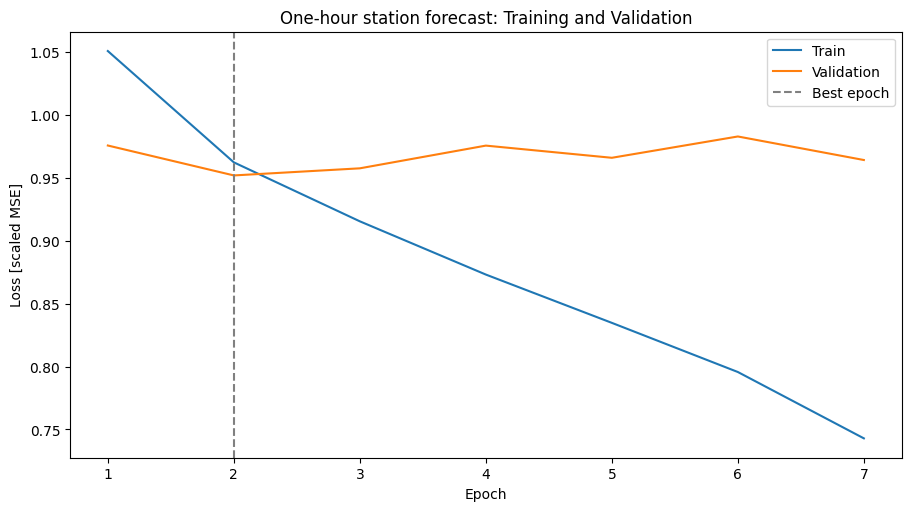

In [38]:
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
epochs = np.arange(1, len(train_loss_list) + 1)
ax.plot(epochs, train_loss_list, label="Train")
ax.plot(epochs, val_loss_list, label="Validation")
ax.axvline(np.argmin(val_loss_list) + 1, color="grey", ls="--", label="Best epoch")
ax.set(xlabel="Epoch", ylabel="Loss [scaled MSE]",
       title="One-hour station forecast: Training and Validation")
ax.legend()
plt.show()


**Input:** The selected station CNN and test images. **Output:** Next-hour station forecasts after adding predicted changes to the current measurements and limiting values to 0–8 oktas.

In [39]:
model.eval()
preds = []
with torch.no_grad():
    for xb, eb, _ in test_loader:
        preds.append(model(xb.to(device), eb.to(device)).cpu().numpy())    # plain forward -> change in oktas
# forecast = cloud amount now + predicted change, kept inside 0-8
preds = np.clip(clamt_now[test_idx] + np.concatenate(preds), 0, 8)
y_true = clamt_future[test_idx]

# baseline 1: persistence = the cloud amount at t stays the same until t + H


**Input:** Training observations, test target hours, and current test observations. **Output:** Persistence, climatology, and hour-of-day reference forecasts.

In [40]:
persistence = clamt_now[test_idx]
climatology = np.broadcast_to(clamt_future[train_idx].mean(axis=0), y_true.shape)
hour_of_day = sat_times[sample_t + H].astype("datetime64[h]").astype(int) % 24
hourly_mean = np.array([
    clamt_future[train_idx][hour_of_day[train_idx] == h].mean(axis=0)
    for h in range(24)
])
diurnal = hourly_mean[hour_of_day[test_idx]]
linear_test = np.clip(clamt_now[test_idx] + lin.predict(extra[test_idx]), 0, 8)


**Input:** All test forecasts and the same observed target hours. **Output:** RMSE in oktas for each method and station, allowing like-for-like comparison.

In [41]:
rmse = lambda a, b: np.sqrt(((a - b) ** 2).mean(axis=0))
for name, p in [
    ("Station CNN", preds), ("persistence", persistence),
    ("linear on extra", linear_test), ("climatology", climatology),
    ("hour-of-day mean", diurnal),
]:
    print(f"{name:18s} RMSE per station {rmse(p, y_true).round(3)} "
          f"overall {overall_rmse(p, y_true):.3f} oktas")


Station CNN        RMSE per station [1.075 1.308 0.982 1.309 1.332] overall 1.210 oktas
persistence        RMSE per station [1.103 1.316 0.985 1.304 1.372] overall 1.225 oktas
linear on extra    RMSE per station [1.056 1.224 0.902 1.217 1.212] overall 1.130 oktas
climatology        RMSE per station [2.339 2.226 1.54  2.188 2.279] overall 2.134 oktas
hour-of-day mean   RMSE per station [2.313 2.233 1.392 2.19  2.283] overall 2.111 oktas


**Input:** Validation loss history. **Output:** The epoch at which the best station checkpoint was selected.

In [42]:
val_loss_list = np.array(val_loss_list)
best_model_idx = np.arange(0,len(val_loss_list))[val_loss_list == best_val]
print(f"Best Model after {best_model_idx[0] +1} epochs with validation loss of {best_val:.4f}")


Best Model after 2 epochs with validation loss of 0.9518


### Recorded versus predicted station cloud amount

**Input:** Test observations and the station CNN and persistence forecasts. **Output:** A time-series view and a scatter plot for Dublin Airport. Points near the 1:1 line indicate more accurate forecasts.

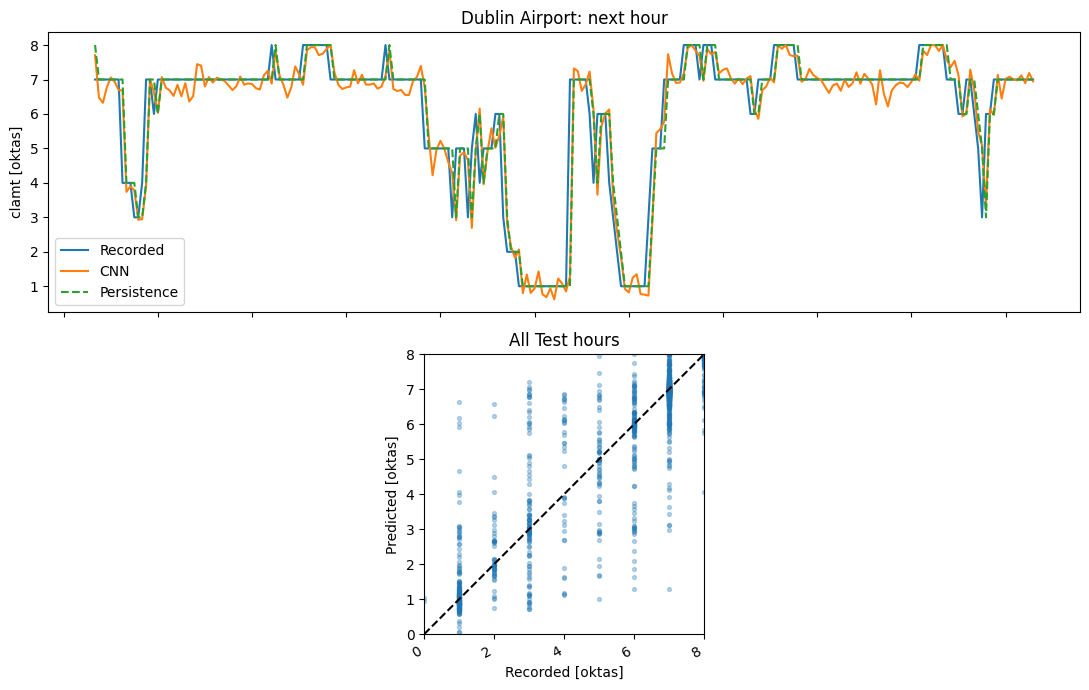

Test bias per station [oktas]: {'Dublin Airport': np.float32(-0.043), 'Cork Airport': np.float32(-0.038), 'Knock Airport': np.float32(-0.071), 'Shannon Airport': np.float32(-0.175), 'Casement': np.float32(0.032)}


In [43]:
station_names = ["Dublin Airport", "Cork Airport", "Knock Airport",
                 "Shannon Airport", "Casement"]
station = 0
count = min(240, len(test_idx))
times_test = sat_times[sample_t[test_idx] + H]
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(times_test[:count], y_true[:count, station], label="Recorded")
axes[0].plot(times_test[:count], preds[:count, station], label="CNN")
axes[0].plot(times_test[:count], persistence[:count, station], ls="--", label="Persistence")
axes[0].set(ylabel="clamt [oktas]", title=f"{station_names[station]}: next hour")
axes[0].legend()
axes[1].scatter(y_true[:, station], preds[:, station], alpha=0.3, s=8)
axes[1].plot([0, 8], [0, 8], ls="--", color="black")
axes[1].set(xlim=(0, 8), ylim=(0, 8), xlabel="Recorded [oktas]",
            ylabel="Predicted [oktas]", title="All Test hours")
axes[1].set_aspect("equal", adjustable="box")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()
print("Test bias per station [oktas]:", dict(zip(
    station_names, np.round((preds - y_true).mean(axis=0), 3)
)))


## Station CNN architecture comparisons

The following three runs compare global versus spatial average pooling and absolute cloud-amount prediction versus change prediction. They reuse the chronological station splits. Each run has its own training and validation history; the map experiment starts after this comparison.

In [44]:
ablation_frames = frames[:, :, ::2, ::2]
ablation_mean, ablation_std = channel_stats(ablation_frames, train_hours)

class AblationStationCNN(nn.Module):
    def __init__(self, grid):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(K * frames.shape[1], 16, stride=stride,
                      padding=padding, kernel_size=kernel_size),
            ConvBlock(16, 32, stride=stride,
                      padding=padding, kernel_size=kernel_size),
            ConvBlock(32, 64, stride=stride,
                      padding=padding, kernel_size=kernel_size),
        )
        self.pool = nn.AdaptiveAvgPool2d(grid)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(64 * grid[0] * grid[1] + extra.shape[1], y.shape[1]),
        )

    def forward(self, images, other_inputs):
        batch, hours, channels, height, width = images.shape
        features = self.features(images.reshape(batch, hours * channels, height, width))
        features = self.pool(features).flatten(1)
        return self.head(torch.cat((features, other_inputs), dim=1))

print("Ablation image shape:", ablation_frames.shape)
print("Ablation input scaling from Train hours only:", len(train_hours))


Ablation image shape: (8784, 2, 45, 60)
Ablation input scaling from Train hours only: 6129


**Input:** Pooling grid, target definition, and the existing station splits. **Output:** A function that trains one CNN, stores its best validation weights, and records scaled MSE by epoch. Absolute and change targets have different scales, so compare their RMSE in oktas rather than raw loss values.

In [45]:
def run_station_ablation(grid, predict_change, label):
    torch.manual_seed(42)
    target = y if predict_change else clamt_future
    target_mean = target[train_idx].mean(axis=0)
    target_std = target[train_idx].std(axis=0)
    target_std = np.where(target_std < 1e-6, 1.0, target_std)

    train_data = FrameDataset(ablation_frames, extra, target, sample_t, train_idx, K)
    validation_data = FrameDataset(ablation_frames, extra, target, sample_t, val_idx, K)
    training = torch.utils.data.DataLoader(
        train_data, batch_size=32, shuffle=True, num_workers=0
    )
    validation = torch.utils.data.DataLoader(
        validation_data, batch_size=64, num_workers=0
    )

    network = ScaledModel(
        AblationStationCNN(grid), ablation_mean, ablation_std,
        target_mean, target_std
    ).to(device)
    optimizer_a = torch.optim.AdamW(
        network.parameters(), lr=3e-4, weight_decay=1e-2
    )
    loss_fn = nn.MSELoss()
    history = {"Train": [], "Validation": []}
    best_loss, best_weights, best_epoch, stale = float("inf"), None, 0, 0

    for epoch in range(1, 13):
        network.train()
        running_train = 0.0
        for xb, eb, yb in training:
            xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
            optimizer_a.zero_grad()
            loss = loss_fn(network.forward_scaled(xb, eb), network.scale_y(yb))
            loss.backward()
            optimizer_a.step()
            running_train += loss.item() * len(xb)

        network.eval()
        running_validation = 0.0
        with torch.no_grad():
            for xb, eb, yb in validation:
                xb, eb, yb = xb.to(device), eb.to(device), yb.to(device)
                v = loss_fn(network.forward_scaled(xb, eb), network.scale_y(yb))
                running_validation += v.item() * len(xb)

        train_loss = running_train / len(train_data)
        val_loss = running_validation / len(validation_data)
        history["Train"].append(train_loss)
        history["Validation"].append(val_loss)
        print(f"{label} | epoch {epoch:02d} | Train {train_loss:.4f} | Validation {val_loss:.4f}")
        if val_loss < best_loss:
            best_loss, best_epoch, stale = val_loss, epoch, 0
            best_weights = copy.deepcopy(network.state_dict())
        else:
            stale += 1
            if stale >= 3:
                break

    network.load_state_dict(best_weights)
    network.eval()
    return {"network": network, "history": history,
            "best_epoch": best_epoch, "delta": predict_change,
            "label": label}


**Input:** Three architecture and target settings. **Output:** Three independently trained station CNN runs using the same time periods; these extra training runs may take time on CPU.

In [46]:
ablation_runs = {}
for label, grid, change in [
    ("Global pool, absolute", (1, 1), False),
    ("Spatial grid, absolute", (3, 4), False),
    ("Spatial grid, change", (3, 4), True),
]:
    ablation_runs[label] = run_station_ablation(grid, change, label)


Global pool, absolute | epoch 01 | Train 0.7235 | Validation 0.8152
Global pool, absolute | epoch 02 | Train 0.6327 | Validation 0.8305
Global pool, absolute | epoch 03 | Train 0.5930 | Validation 0.7231
Global pool, absolute | epoch 04 | Train 0.5626 | Validation 0.7288
Global pool, absolute | epoch 05 | Train 0.5462 | Validation 0.6658
Global pool, absolute | epoch 06 | Train 0.5308 | Validation 0.6498
Global pool, absolute | epoch 07 | Train 0.5159 | Validation 0.7558
Global pool, absolute | epoch 08 | Train 0.5140 | Validation 0.6286
Global pool, absolute | epoch 09 | Train 0.4992 | Validation 0.6714
Global pool, absolute | epoch 10 | Train 0.4946 | Validation 0.6177
Global pool, absolute | epoch 11 | Train 0.4880 | Validation 0.6163
Global pool, absolute | epoch 12 | Train 0.4800 | Validation 0.6342
Spatial grid, absolute | epoch 01 | Train 0.6448 | Validation 0.7278
Spatial grid, absolute | epoch 02 | Train 0.5370 | Validation 0.6734
Spatial grid, absolute | epoch 03 | Train 0.49

**Input:** The three recorded loss histories. **Output:** Separate training/validation curves and the best validation epoch for each run. A rising validation curve alongside falling training loss suggests overfitting in that run.

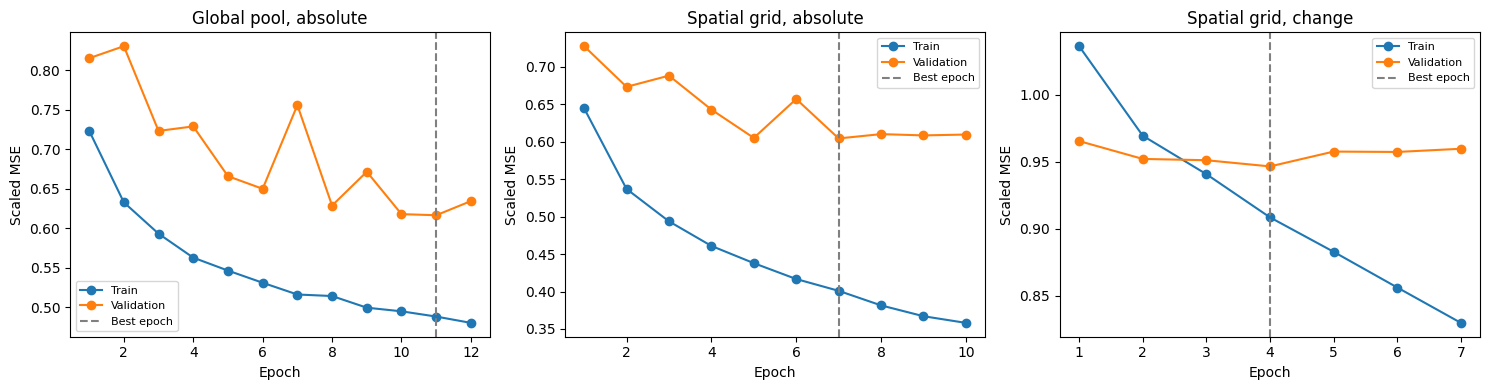

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (label, run) in zip(axes, ablation_runs.items()):
    epochs = np.arange(1, len(run["history"]["Train"]) + 1)
    ax.plot(epochs, run["history"]["Train"], marker="o", label="Train")
    ax.plot(epochs, run["history"]["Validation"], marker="o", label="Validation")
    ax.axvline(run["best_epoch"], color="grey", linestyle="--", label="Best epoch")
    ax.set(title=label, xlabel="Epoch", ylabel="Scaled MSE")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


**Input:** Predictions from the three runs and the same validation observations. **Output:** Comparable RMSE in oktas for absolute, change, and persistence forecasts. Validation guides model selection; test remains the final evaluation period.

In [48]:
ablation_truth = clamt_future[val_idx]
persistence_val_rmse = overall_rmse(clamt_now[val_idx], ablation_truth)
print(f"Persistence | Validation RMSE {persistence_val_rmse:.3f} oktas")

for label, run in ablation_runs.items():
    validation_data = FrameDataset(
        ablation_frames, extra, y, sample_t, val_idx, K
    )
    loader = torch.utils.data.DataLoader(
        validation_data, batch_size=64, num_workers=0
    )
    forecast_parts = []
    run["network"].eval()
    with torch.no_grad():
        for xb, eb, _ in loader:
            forecast_parts.append(
                run["network"](xb.to(device), eb.to(device)).cpu().numpy()
            )
    predictions = np.concatenate(forecast_parts)
    if run["delta"]:
        predictions += clamt_now[val_idx]
    predictions = np.clip(predictions, 0, 8)
    print(f"{label:<25} | Validation RMSE "
          f"{overall_rmse(predictions, ablation_truth):.3f} oktas")


Persistence | Validation RMSE 1.206 oktas
Global pool, absolute     | Validation RMSE 1.572 oktas
Spatial grid, absolute    | Validation RMSE 1.537 oktas
Spatial grid, change      | Validation RMSE 1.189 oktas


# Experiment 2: next-hour satellite cloud map

The CNN–LSTM takes six hourly satellite maps and predicts the next cloud mask and cloud-top height map. The station CSV values are not model inputs in this experiment. The final map plots show the six inputs, the recorded target, the prediction, and the spatial errors.

**Input:** Shared imports. **Output:** Path and PyTorch loss utilities used in the map experiment.

In [49]:
from pathlib import Path
from torch.nn import functional as F


**Input:** Hourly satellite masks. **Output:** Six-frame sequences whose input and next-hour target all contain valid pixels; fully missing frames are excluded.

In [50]:
map_hour_ok = np.any(cloud_mask != 3, axis=(1, 2))
map_sample_t = np.array([
    t for t in range(K - 1, len(sat_times) - 1)
    if map_hour_ok[t - K + 1:t + 2].all()
])


**Input:** Map sample indices and the chronological boundaries. **Output:** Map train, validation, and test sets with every input and target within one time period.

In [51]:
map_first_input = map_sample_t - K + 1
map_target_hour = map_sample_t + 1
map_idx = np.arange(len(map_sample_t))
map_train_idx = map_idx[map_target_hour < train_end]
map_val_idx = map_idx[
    (map_first_input >= train_end) & (map_target_hour < validation_end)
]
map_test_idx = map_idx[map_first_input >= validation_end]


**Input:** Map split indices. **Output:** A check that no satellite hour is shared between the three map partitions.

In [52]:
def used_map_hours(indices):
    last_inputs = map_sample_t[indices]
    return set(np.concatenate(
        [last_inputs - offset for offset in range(K)] + [last_inputs + 1]
    ))

map_train_hours = used_map_hours(map_train_idx)
map_validation_hours = used_map_hours(map_val_idx)
map_test_hours = used_map_hours(map_test_idx)
assert map_train_hours.isdisjoint(map_validation_hours)
assert map_train_hours.isdisjoint(map_test_hours)
assert map_validation_hours.isdisjoint(map_test_hours)


**Input:** Map split indices and timestamps. **Output:** Example counts and the input/target times to verify the one-hour horizon.

In [53]:
map_total = sum(map(len, (map_train_idx, map_val_idx, map_test_idx)))
for name, indices in [
    ("Train", map_train_idx), ("Validation", map_val_idx),
    ("Test", map_test_idx),
]:
    print(f"{name}: {len(indices)} ({100 * len(indices) / map_total:.1f}%)")
print("Verified: input and target hours do not overlap across splits.")
print("First six input times:", sat_times[map_sample_t[0] - K + 1:map_sample_t[0] + 1])
print("First next-hour target:", sat_times[map_sample_t[0] + 1])


Train: 6104 (69.9%)
Validation: 1312 (15.0%)
Test: 1312 (15.0%)
Verified: input and target hours do not overlap across splits.
First six input times: ['2024-01-01T00:00:00.000000' '2024-01-01T01:00:00.000000'
 '2024-01-01T02:00:00.000000' '2024-01-01T03:00:00.000000'
 '2024-01-01T04:00:00.000000' '2024-01-01T05:00:00.000000']
First next-hour target: 2024-01-01T06:00:00.000000


## Map tensors and valid pixels

Each input hour has three `90 × 120` channels: cloud presence, cloud-top height divided by 12 km, and a valid-pixel flag. The target contains next-hour cloud and height maps plus masks identifying where each target can be evaluated. Missing pixels are excluded from the cloud loss, and height loss uses observed cloudy pixels with valid heights.

**Input:** Six satellite frames and their next-hour target. **Output:** Map dataset items containing image sequences, cloud and height targets, and validity masks.

In [54]:
class NextHourMapDataset(torch.utils.data.Dataset):
    def __init__(self, indices):
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        t = map_sample_t[self.indices[item]]
        previous = frames[t - K + 1:t + 1].astype(np.float32)
        cloud_inputs = previous[:, 0]
        height_inputs = np.clip(previous[:, 1] / 12, 0, 1)
        valid_inputs = (cloud_mask[t - K + 1:t + 1] != 3).astype(np.float32)
        images = np.stack((cloud_inputs, height_inputs, valid_inputs), axis=1)

        target_mask = cloud_mask[t + 1]
        target_cloud = (target_mask == 2).astype(np.float32)[None]
        target_height = np.clip(frames[t + 1, 1].astype(np.float32) / 12, 0, 1)[None]
        target_valid = (target_mask != 3).astype(np.float32)[None]
        height_valid = (target_mask == 2).astype(np.float32)[None]

        return tuple(torch.from_numpy(array) for array in (
            images, target_cloud, target_height, target_valid, height_valid,
        ))


**Input:** The chronological map indices. **Output:** Map datasets for training, validation, and test.

In [55]:
map_train_dataset = NextHourMapDataset(map_train_idx)
map_val_dataset = NextHourMapDataset(map_val_idx)
map_test_dataset = NextHourMapDataset(map_test_idx)


**Input:** The three map datasets. **Output:** Data loaders with batches of eight map examples.

In [56]:
map_train_loader = torch.utils.data.DataLoader(
    map_train_dataset, batch_size=8, shuffle=True, num_workers=0
)
map_val_loader = torch.utils.data.DataLoader(
    map_val_dataset, batch_size=8, num_workers=0
)
map_test_loader = torch.utils.data.DataLoader(
    map_test_dataset, batch_size=8, num_workers=0
)


**Input:** One training example. **Output:** Printed tensor dimensions to check the six-frame, three-channel input and one-channel target maps before model training.

In [57]:
example_images, example_cloud, example_height, _, _ = map_train_dataset[0]
print("Input images:", example_images.shape)
print("Next-hour cloud target:", example_cloud.shape)
print("Next-hour height target:", example_height.shape)


Input images: torch.Size([6, 3, 90, 120])
Next-hour cloud target: torch.Size([1, 90, 120])
Next-hour height target: torch.Size([1, 90, 120])


## CNN–LSTM: from six images to a next-hour map

The same CNN encoder processes each of the six hourly images with shared weights. The LSTM then reads six encoded feature vectors in time order at each spatial grid location. Dimensions below omit the batch axis.

| Layer | Input → output | Operation and purpose |
| --- | --- | --- |
| CNN layer 1 | `3 × 90 × 120` → `8 × 45 × 60` | `Conv2d(3, 8, 3, stride=2, padding=1)` and `ReLU`. |
| CNN layer 2 | `8 × 45 × 60` → `16 × 23 × 30` | `Conv2d(8, 16, 3, stride=2, padding=1)` and `ReLU`; no pooling is used here. |
| Spatial LSTM | `6 × 16 × 23 × 30` → `16 × 23 × 30` | At each of 690 positions, read six steps with `input_size=16`, `hidden_size=16`; keep the final hidden output. |
| Upsample and skip | `16 × 23 × 30` → `16 × 90 × 120` → `19 × 90 × 120` | Bilinear upsampling followed by concatenation with the latest original three-channel image. |
| Decoder | `19 × 90 × 120` → `16 × 90 × 120` | Two `3 × 3` convolutions with `padding=1`, `stride=1`, and `ReLU`. |
| Cloud head | `16 × 90 × 120` → `1 × 90 × 120` | A `1 × 1` convolution adjusts latest-map cloud logits; sigmoid and a 0.5 threshold produce the plotted mask. |
| Height head | `16 × 90 × 120` → `1 × 90 × 120` | A `1 × 1` convolution adjusts the latest height estimate; sigmoid bounds the output to 0–1, equivalent to 0–12 km. |

The strided encoder reduces resolution, while the last-image skip supplies full-resolution information to the decoder. The numbers 8 and 16 are feature channels; `hidden_size=16` applies to each grid position.

**Input:** Six three-channel satellite maps. **Output:** A model returning next-hour cloud logits and normalized height predictions. Its `forward` pass combines a shared CNN encoder, spatial LSTM, full-resolution skip, and two output heads.

In [58]:
class NextHourCloudMapModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 8, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.map_lstm = nn.LSTM(16, 16, batch_first=True)
        self.decoder = nn.Sequential(
            nn.Conv2d(16 + 3, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
        )
        self.cloud_head = nn.Conv2d(16, 1, 1)
        self.height_head = nn.Conv2d(16, 1, 1)

    def forward(self, images):
        batch, hours, channels, height, width = images.shape
        encoded = self.encoder(
            images.reshape(batch * hours, channels, height, width)
        )
        _, features, small_h, small_w = encoded.shape
        encoded = encoded.reshape(batch, hours, features, small_h, small_w)
        sequences = encoded.permute(0, 3, 4, 1, 2).reshape(
            batch * small_h * small_w, hours, features
        )
        sequences, _ = self.map_lstm(sequences)
        spatial = sequences[:, -1].reshape(batch, small_h, small_w, 16)
        spatial = spatial.permute(0, 3, 1, 2)
        spatial = F.interpolate(
            spatial, size=(height, width), mode="bilinear", align_corners=False
        )

        last_image = images[:, -1]  # retains full 90 x 120 detail
        decoded = self.decoder(torch.cat((spatial, last_image), dim=1))
        cloud_logits = 4 * last_image[:, 0:1] - 2 + self.cloud_head(decoded)

        previous_height = torch.where(
            last_image[:, 0:1] > 0.5,
            last_image[:, 1:2],
            torch.full_like(last_image[:, 1:2], 0.5),
        ).clamp(0.01, 0.99)
        predicted_height = torch.sigmoid(
            torch.logit(previous_height) + self.height_head(decoded)
        )
        return cloud_logits, predicted_height


**Input:** The CNN–LSTM class. **Output:** A map model on the available GPU or CPU.

In [59]:
map_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
map_model = NextHourCloudMapModel().to(map_device)
print("Cloud-map device:", map_device)


Cloud-map device: cpu


**Input:** One six-frame example. **Output:** A gradient-free shape check: both predicted maps must match the one-channel 90 × 120 targets.

In [60]:
with torch.no_grad():
    cloud_logits, predicted_height = map_model(
        example_images[None].to(map_device)
    )
print("Model outputs:", cloud_logits.shape, predicted_height.shape)


Model outputs: torch.Size([1, 1, 90, 120]) torch.Size([1, 1, 90, 120])


## Map loss, gradients, and updates

The cloud head returns logits. `binary_cross_entropy_with_logits` measures cloud/clear error over valid target pixels. `smooth_l1_loss` measures normalized cloud-top-height error only where target pixels have observed cloud and valid heights. Height is divided by 12 km during training.

Combined loss = `cloud BCE + 5 × height SmoothL1`. The factor 5 weights the height term; it does not represent 5 km. During each training batch: `zero_grad()` → CNN–LSTM forward pass → combined loss → `backward()` through both heads, decoder, LSTM, and encoder → `Adam.step()`. Validation never updates weights; the checkpoint with lowest validation loss is retained.

**Input:** Predicted logits/heights, target maps, and validity masks. **Output:** Cloud BCE plus five times height SmoothL1, calculated only where the corresponding target is valid.

In [61]:
def map_loss(scores, predicted_h, target_cloud, target_h, valid, height_valid):
    cloud_loss = F.binary_cross_entropy_with_logits(
        scores[valid.bool()], target_cloud[valid.bool()]
    )
    cloudy_pixels = height_valid.bool()
    if cloudy_pixels.any():
        height_loss = F.smooth_l1_loss(
            predicted_h[cloudy_pixels], target_h[cloudy_pixels]
        )
    else:
        height_loss = cloud_loss.new_zeros(())
    return cloud_loss + 5 * height_loss


**Input:** Map predictions and target masks. **Output:** An evaluation function that computes cloud IoU, height MAE in kilometres, and map loss; it can also score last-map persistence.

In [62]:
@torch.no_grad()
def map_metrics(loader, baseline=False):
    map_model.eval()
    loss_total = intersection = union = height_error = height_count = 0.0
    for batch in loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        if baseline:
            cloud_prediction = images[:, -1, 0:1] > 0.5
            predicted_h = images[:, -1, 1:2]
        else:
            scores, predicted_h = map_model(images)
            loss_total += map_loss(
                scores, predicted_h, cloud, height, valid, height_valid
            ).item() * len(images)
            cloud_prediction = torch.sigmoid(scores) >= 0.5

        valid_pixels = valid.bool()
        actual_cloud = cloud.bool()
        intersection += (
            cloud_prediction & actual_cloud & valid_pixels
        ).sum().item()
        union += (
            (cloud_prediction | actual_cloud) & valid_pixels
        ).sum().item()
        height_pixels = height_valid.bool()
        height_error += (
            (predicted_h[height_pixels] - height[height_pixels]).abs().sum().item()
            * 12
        )
        height_count += height_pixels.sum().item()

    return (
        loss_total / len(loader.dataset) if not baseline else float("nan"),
        100 * intersection / union,
        height_error / height_count,
    )


### Last-map persistence

**Input:** Latest input maps and observed next-hour maps. **Output:** Validation and test cloud IoU and height MAE for a forecast that carries the last image forward.

In [63]:
_, baseline_val_iou, baseline_val_height = map_metrics(map_val_loader, baseline=True)
_, baseline_test_iou, baseline_test_height = map_metrics(map_test_loader, baseline=True)
print(f"Last map Validation: IoU {baseline_val_iou:.1f}% | "
      f"height MAE {baseline_val_height:.2f} km")
print(f"Last map Test: IoU {baseline_test_iou:.1f}% | "
      f"height MAE {baseline_test_height:.2f} km")


Last map Validation: IoU 82.7% | height MAE 1.47 km
Last map Test: IoU 83.8% | height MAE 1.58 km


**Input:** Map model and output path. **Output:** An Adam optimizer with learning rate `0.001`, separate loss histories, and a checkpoint location.

In [64]:
map_output_dir = Path("outputs/project2_next_cloud_map_one_hour_aligned")
map_output_dir.mkdir(parents=True, exist_ok=True)
map_checkpoint = map_output_dir / "best_next_cloud_map.pt"
map_optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)
map_train_history, map_val_history = [], []
best_map_loss = float("inf")
stale_map_epochs = 0


**Input:** Map training and validation batches. **Output:** Per-epoch combined loss, cloud IoU, height MAE, and the lowest-validation-loss checkpoint. Training runs forward → loss → backward → update; early stopping follows three epochs without validation improvement.

In [65]:
for map_epoch in range(1, 9):
    map_model.train()
    training_total = 0.0
    for batch in map_train_loader:
        images, cloud, height, valid, height_valid = (
            item.to(map_device) for item in batch
        )
        map_optimizer.zero_grad()
        scores, predicted_h = map_model(images)
        loss = map_loss(scores, predicted_h, cloud, height, valid, height_valid)
        loss.backward()
        map_optimizer.step()
        training_total += loss.item() * len(images)

    training_loss = training_total / len(map_train_dataset)
    validation_loss, validation_iou, validation_height_mae = map_metrics(
        map_val_loader
    )
    map_train_history.append(training_loss)
    map_val_history.append(validation_loss)
    print(
        f"Epoch {map_epoch:02d} | Train loss {training_loss:.4f} | "
        f"Validation loss {validation_loss:.4f} | "
        f"Cloud IoU {validation_iou:.1f}% | "
        f"Height MAE {validation_height_mae:.2f} km",
        flush=True,
    )
    if validation_loss < best_map_loss:
        best_map_loss = validation_loss
        stale_map_epochs = 0
        torch.save(map_model.state_dict(), map_checkpoint)
        print("  Saved best next-hour map model", flush=True)
    else:
        stale_map_epochs += 1
        if stale_map_epochs >= 3:
            print("Stopped after three epochs without validation improvement")
            break


Epoch 01 | Train loss 0.4142 | Validation loss 0.3985 | Cloud IoU 84.1% | Height MAE 1.44 km
  Saved best next-hour map model
Epoch 02 | Train loss 0.3732 | Validation loss 0.3819 | Cloud IoU 84.3% | Height MAE 1.34 km
  Saved best next-hour map model
Epoch 03 | Train loss 0.3647 | Validation loss 0.3784 | Cloud IoU 84.4% | Height MAE 1.44 km
  Saved best next-hour map model
Epoch 04 | Train loss 0.3607 | Validation loss 0.3762 | Cloud IoU 84.4% | Height MAE 1.38 km
  Saved best next-hour map model
Epoch 05 | Train loss 0.3580 | Validation loss 0.3662 | Cloud IoU 84.5% | Height MAE 1.34 km
  Saved best next-hour map model
Epoch 06 | Train loss 0.3561 | Validation loss 0.3675 | Cloud IoU 84.5% | Height MAE 1.31 km
Epoch 07 | Train loss 0.3543 | Validation loss 0.3642 | Cloud IoU 84.6% | Height MAE 1.35 km
  Saved best next-hour map model
Epoch 08 | Train loss 0.3533 | Validation loss 0.3627 | Cloud IoU 84.6% | Height MAE 1.35 km
  Saved best next-hour map model


**Input:** Saved best map weights. **Output:** The map model restored for the final test evaluation and visual comparison.

In [66]:
map_model.load_state_dict(
    torch.load(map_checkpoint, map_location=map_device, weights_only=True)
)
map_model.eval()
print("Best model:", map_checkpoint)


Best model: outputs\project2_next_cloud_map_one_hour_aligned\best_next_cloud_map.pt


## Evaluate map predictions

Cloud IoU measures agreement in the predicted cloud pixels; height MAE reports the absolute cloud-top-height error in kilometres. The map loss has a different definition and scale from the station CNN’s scaled MSE.

### Interpreting the map loss curve

**Input:** Recorded map training and validation losses. **Output:** Combined cloud/height loss by completed epoch. Falling training loss with sustained rising validation loss suggests overfitting. A validation curve that changes little over several epochs suggests a plateau. Select the checkpoint at the lowest validation loss; use IoU and height MAE to describe map quality.

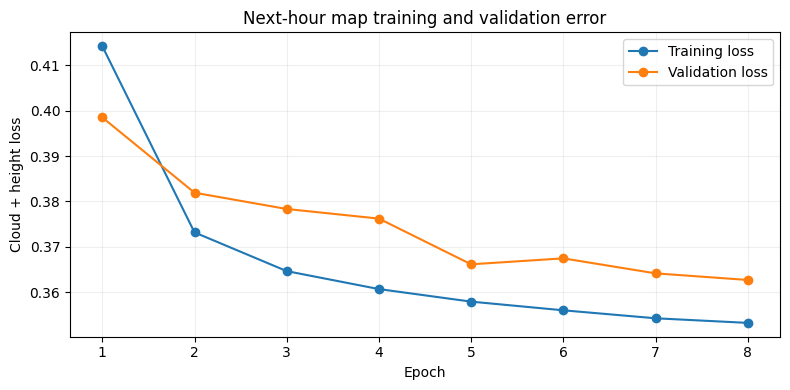

In [67]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs = np.arange(1, len(map_train_history) + 1)
ax.plot(epochs, map_train_history, marker="o", label="Training loss")
ax.plot(epochs, map_val_history, marker="o", label="Validation loss")
ax.set(xlabel="Epoch", ylabel="Cloud + height loss",
       title="Next-hour map training and validation error")
ax.set_xticks(epochs)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
fig.savefig(map_output_dir / "training_error.png", dpi=160)
plt.show()


**Input:** CNN–LSTM and last-map forecasts for the same test hours. **Output:** Cloud IoU (higher is better) and height MAE in kilometres (lower is better) for both methods.

In [68]:
test_loss, test_iou, test_height_mae = map_metrics(map_test_loader)
_, baseline_iou, baseline_height_mae = map_metrics(map_test_loader, baseline=True)
print(f"CNN–LSTM | Test cloud IoU: {test_iou:.1f}% | "
      f"Height MAE: {test_height_mae:.2f} km")
print(f"Last map | Test cloud IoU: {baseline_iou:.1f}% | "
      f"Height MAE: {baseline_height_mae:.2f} km")


CNN–LSTM | Test cloud IoU: 85.7% | Height MAE: 1.42 km
Last map | Test cloud IoU: 83.8% | Height MAE: 1.58 km


## Plot recorded and predicted maps

The following cells prepare one test example, draw its six inputs, recorded next-hour map, and predicted next-hour map, then plot cloud and height errors.

**Input:** Plotting libraries. **Output:** Discrete colour-map and geographic-coordinate tools for the satellite map panels.

In [69]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

try:
    import cartopy.crs as ccrs
except ImportError:
    ccrs = None  # Geographic coordinates still plot without Cartopy.


**Input:** Test map dataset. **Output:** The index of one example to inspect visually; overall test metrics describe performance across all test hours.

In [70]:
map_example_number = 100


**Input:** Six test frames. **Output:** Next-hour cloud logits and predicted height from a forward pass without gradients or parameter updates.

In [71]:
input_images, actual_cloud_t, actual_h_t, valid_t, _ = map_test_dataset[
    map_example_number
]
map_last_hour = map_sample_t[map_test_idx[map_example_number]]
with torch.no_grad():
    map_scores, map_height = map_model(input_images[None].to(map_device))


**Input:** Predicted and recorded map tensors. **Output:** Binary cloud maps, validity masks, and cloud-top heights in kilometres for plotting.

In [72]:
pred_cloud = (torch.sigmoid(map_scores[0, 0]) >= 0.5).cpu().numpy()
pred_height_km = (map_height[0, 0] * 12).cpu().numpy()
actual_cloud_map = actual_cloud_t[0].bool().numpy()
actual_height_km = actual_h_t[0].numpy() * 12
valid_pixels = valid_t[0].bool().numpy()


**Input:** Satellite coordinates and selected example index. **Output:** Latitude, longitude, and timestamps for the six inputs and target map.

In [73]:
lat = sat_data["lat"]
lon = sat_data["lon"]
observed_positions = list(range(map_last_hour - K + 1, map_last_hour + 2))


**Input:** Known land pixels, latest satellite mask, and predicted cloud pixels. **Output:** A display mask with sea/land background and predicted cloud overlay; the model does not predict land type.

In [74]:
land_pixels = np.any(cloud_mask[map_sample_t[map_train_idx]] == 1, axis=0)
predicted_mask = np.where(land_pixels, 1, 0).astype(np.uint8)
predicted_mask[pred_cloud] = 2
predicted_mask[cloud_mask[map_last_hour] == 3] = 3


**Input:** Satellite mask categories. **Output:** A shared palette: clear sea `#0161c2`, clear land `#09773e`, cloud `#8e63b9`, and missing data white. The `Purples` gradient shows 0–12 km cloud-top height.

In [75]:
background = ListedColormap(["#0161c2", "#09773e", "#8e63b9", "#ffffff"])
mask_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)
projection = {"projection": ccrs.PlateCarree()} if ccrs else {}
transform = {"transform": ccrs.PlateCarree()} if ccrs else {}


**Input:** Six observed inputs and the actual and predicted next-hour maps. **Output:** Eight map panels with the same colours and height range, so visual comparisons use one consistent scale.

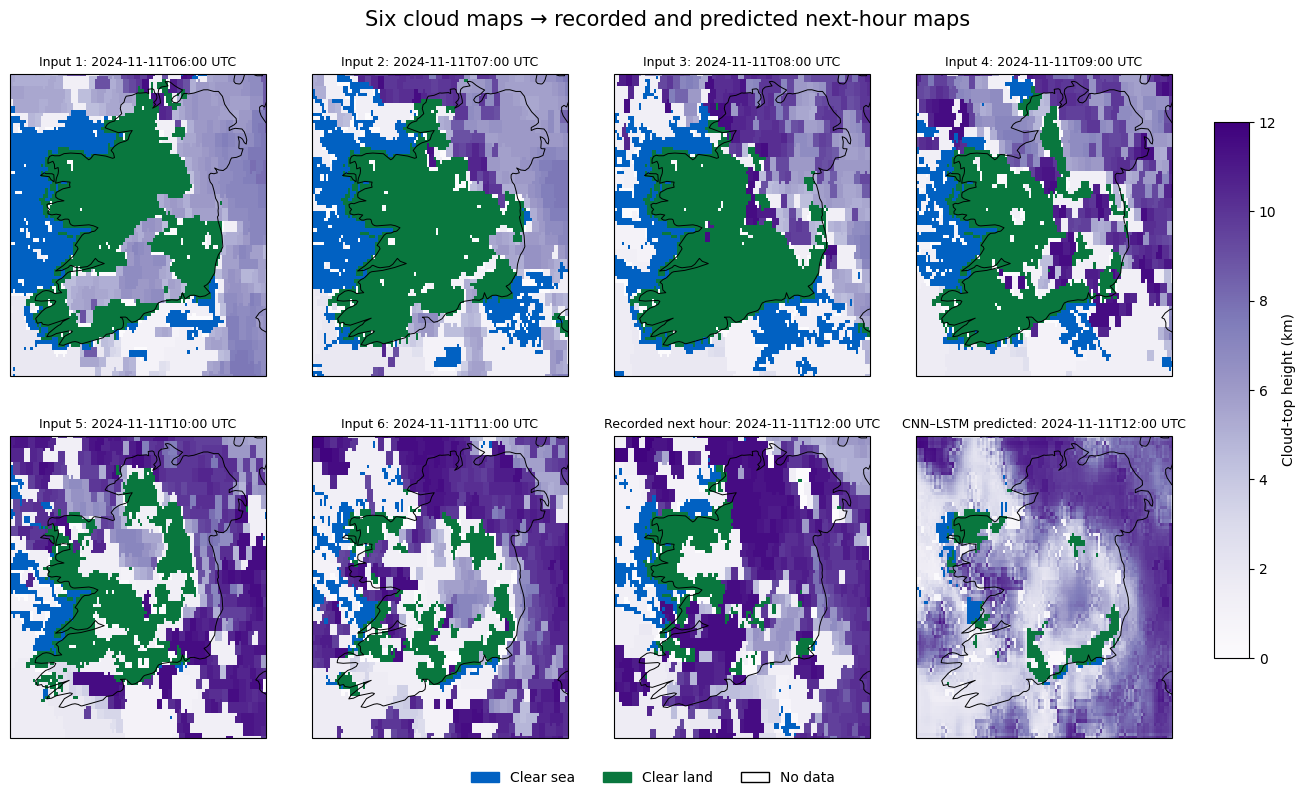

In [76]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8), subplot_kw=projection)
fig.subplots_adjust(left=0.03, right=0.86, bottom=0.07, top=0.90,
                    wspace=0.18, hspace=0.20)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = observed_positions[panel]
        panel_mask = cloud_mask[position]
        panel_height = frames[position, 1].astype(np.float32)
        title = f"Input {panel + 1}" if panel < 6 else "Recorded next hour"
    else:
        position = map_last_hour + 1
        panel_mask = predicted_mask
        panel_height = pred_height_km
        title = "CNN–LSTM predicted"

    ax.pcolormesh(lon, lat, panel_mask, cmap=background, norm=mask_norm,
                  shading="auto", **transform)
    coloured_clouds = ax.pcolormesh(
        lon, lat, np.ma.masked_where(panel_mask != 2, panel_height),
        cmap="Purples", vmin=0, vmax=12, shading="auto", **transform
    )
    if ccrs:
        ax.coastlines(resolution="50m", color="black", linewidth=0.7)
        ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()],
                      crs=ccrs.PlateCarree())
    else:
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
    ax.set_aspect("auto")
    ax.set_title(f"{title}: {str(sat_times[position])[:16]} UTC", fontsize=9)

fig.suptitle("Six cloud maps → recorded and predicted next-hour maps", fontsize=15)
fig.legend(handles=[
    Patch(color="#0161c2", label="Clear sea"),
    Patch(color="#09773e", label="Clear land"),
    Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
], loc="lower center", ncol=3, frameon=False)
fig.colorbar(coloured_clouds, cax=fig.add_axes([0.89, 0.17, 0.025, 0.67]),
             label="Cloud-top height (km)")
fig.savefig(map_output_dir / "recorded_vs_predicted.png", dpi=160,
            bbox_inches="tight")
plt.show()

# Error maps for this example; never use the recorded target as a model input.


**Input:** Predicted and observed cloud and height maps. **Output:** Pixel categories for false clouds and missed clouds, and absolute height error wherever comparison is valid.

In [77]:
pixel_error = np.zeros_like(predicted_mask)
pixel_error[pred_cloud & ~actual_cloud_map & valid_pixels] = 1  # false cloud
pixel_error[~pred_cloud & actual_cloud_map & valid_pixels] = 2  # missed cloud
pixel_error[~valid_pixels] = 3
error_cmap = ListedColormap(["#e4f3e4", "#ff9933", "#d63247", "#ffffff"])
error_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], error_cmap.N)
height_error_map = np.ma.masked_where(
    ~actual_cloud_map, np.abs(pred_height_km - actual_height_km)
)


**Input:** Pixel error categories and height differences. **Output:** Separate spatial plots of cloud mistakes and cloud-top-height error in kilometres.

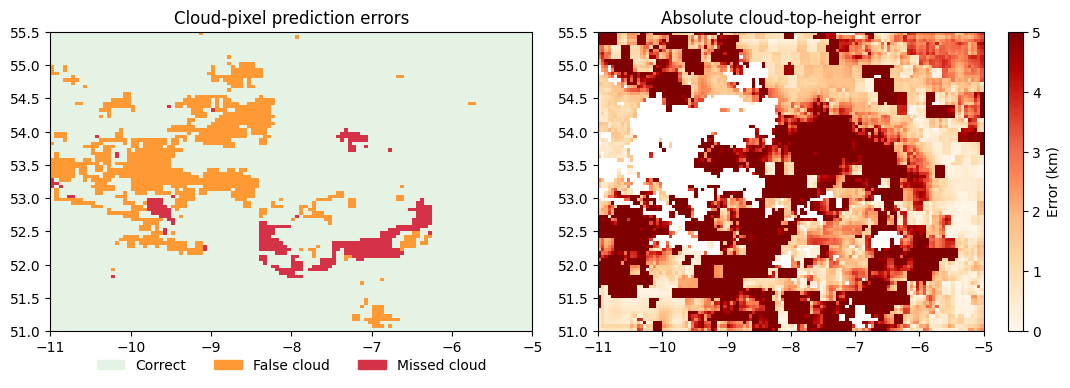

In [78]:
fig, (ax_cloud, ax_height) = plt.subplots(1, 2, figsize=(11, 4))
ax_cloud.pcolormesh(lon, lat, pixel_error, cmap=error_cmap,
                    norm=error_norm, shading="auto")
ax_cloud.set_title("Cloud-pixel prediction errors")
ax_cloud.legend(handles=[
    Patch(color="#e4f3e4", label="Correct"),
    Patch(color="#ff9933", label="False cloud"),
    Patch(color="#d63247", label="Missed cloud"),
], loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
colours = ax_height.pcolormesh(lon, lat, height_error_map,
                               cmap="OrRd", vmin=0, vmax=5, shading="auto")
ax_height.set_title("Absolute cloud-top-height error")
fig.colorbar(colours, ax=ax_height, label="Error (km)")
fig.tight_layout()
fig.savefig(map_output_dir / "example_error_maps.png", dpi=160,
            bbox_inches="tight")
plt.show()


**Input:** Output directory. **Output:** Locations of the saved training-loss, comparison, and error-map figures.

In [79]:
print("Saved training_error.png, recorded_vs_predicted.png, and "
      "example_error_maps.png in", map_output_dir.resolve())


Saved training_error.png, recorded_vs_predicted.png, and example_error_maps.png in D:\PhD\radar_cnn_lstm\outputs\project2_next_cloud_map_one_hour_aligned
